In [1]:
%load_ext autoreload
%autoreload 2

# IMPORTS

In [2]:
# project setup
from pathlib import Path
import sys

project_root = Path.cwd().parent

if str(project_root) not in sys.path:
    sys.path.append(str(project_root))

In [11]:
import warnings

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import torch
from sklearn.metrics import confusion_matrix, f1_score, roc_auc_score, roc_curve
from sklearn.model_selection import train_test_split
from torch.utils.data import Dataset
from transformers import (
    AutoModelForSequenceClassification,
    AutoTokenizer,
    Trainer,
    TrainingArguments,
)

from src.config import HEATMAP_CMAP, RANDOM_STATE
from src.preprocessing import TextCleaner, prepare_data, prepare_target

# settings
warnings.filterwarnings('ignore', category=UserWarning)

# Classes & Functions

In [7]:
class AirlineDataset(Dataset):
    """Custom PyTorch Dataset for handling tokenized text encodings and labels.

    Converts pre-tokenized features and target labels into PyTorch tensors
    suitable for training and evaluating Transformer models.

    Args:
        encodings (dict): A dictionary containing tokenized input data, where
            keys are input names (e.g., 'input_ids', 'attention_mask') and values
            are lists or arrays of token IDs.
        labels (pd.Series or np.ndarray): Target labels corresponding to each
            text sample.

    Attributes:
        encodings (dict): The stored dictionary of input encodings.
        labels (list): Target labels converted to a Python list.
    """
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels.tolist()

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        item = {
            key: torch.tensor(val[idx])
            for key, val in self.encodings.items()
        }
        item['labels'] = torch.tensor(self.labels[idx])

        return item

In [4]:
def compute_metrics(eval_pred):
    """Compute evaluation metrics for model predictions.

    Calculates the F1 score and Area Under the Receiver Operating Characteristic
    Curve (AUROC) for binary classification evaluation.

    Args:
        eval_pred (tuple): A tuple containing `(logits, labels)`:
            - logits (np.ndarray): Raw model outputs of shape (batch_size, num_classes).
            - labels (np.ndarray): Ground truth target labels.

    Returns:
        dict: A dictionary containing the evaluated metrics:
            - "f1" (float): F1 score based on predicted class labels.
            - "auroc" (float): Area under the ROC curve based on positive class probabilities.
    """
    logits, labels = eval_pred

    probabilities = np.exp(logits) / np.exp(logits).sum(axis=1, keepdims=True)
    predictions = np.argmax(logits, axis=1)

    return {
        'f1': f1_score(labels, predictions),
        'auroc': roc_auc_score(labels, probabilities[:, 1])
    }

# Load data & Split data

In [8]:
# and access the dataset in data
data_path = project_root / 'data' / 'Airline_review.csv'
raw_df = pd.read_csv(data_path)

# remove duplicate reviews
raw_df = raw_df.drop_duplicates(
    subset=raw_df.columns.drop('Unnamed: 0'),
    ignore_index=True
)

# split the raw data into training-validation and test sets (80/20)
train_val_df, test_df = train_test_split(
    raw_df,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=raw_df['Recommended']
)

# split the training-validation data into training and validation sets (80/20)
train_df, val_df = train_test_split(
    train_val_df,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=train_val_df['Recommended']
)

# columns to remove before modeling
cols_to_drop = [
    'Unnamed: 0',
    'Review Date',
    'Verified',
    'Route',
    'Airline Name',
    'Overall_Rating',
    'Aircraft',
    'Date Flown'
]

# data preparation
train_df = prepare_data(train_df, cols_to_drop)
val_df = prepare_data(val_df, cols_to_drop)
test_df = prepare_data(test_df, cols_to_drop)

# target preparation
train_df = prepare_target(train_df)
val_df = prepare_target(val_df)
test_df = prepare_target(test_df)

y_train = train_df['Recommended_num']
y_val = val_df['Recommended_num']
y_test = test_df['Recommended_num']

In [9]:
text_cleaner = TextCleaner()

train_texts = text_cleaner.transform(train_df['Review'])
val_texts = text_cleaner.transform(val_df['Review'])
test_texts = text_cleaner.transform(test_df['Review'])

# BERT

In [ ]:
MODEL_NAME = 'bert-base-uncased'
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

In [11]:
# encodings
train_encodings = tokenizer(
    train_texts.tolist(),
    truncation=True,
    padding=True,
    max_length=256
)

val_encodings = tokenizer(
    val_texts.tolist(),
    truncation=True,
    padding=True,
    max_length=256
)

test_encodings = tokenizer(
    test_texts.tolist(),
    truncation=True,
    padding=True,
    max_length=256
)

In [12]:
train_dataset = AirlineDataset(train_encodings, y_train)
val_dataset = AirlineDataset(val_encodings, y_val)
test_dataset = AirlineDataset(test_encodings, y_test)

In [ ]:
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=2
)

In [14]:
training_args = TrainingArguments(
    output_dir='./bert_airline_results',
    eval_strategy='epoch',
    save_strategy='epoch',
    learning_rate=2e-5,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    num_train_epochs=3,
    weight_decay=0.01,
    load_best_model_at_end=True,
    metric_for_best_model='f1',
    greater_is_better=True,
    report_to='none'
)

In [15]:
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    compute_metrics=compute_metrics
)

In [ ]:
trainer.train()

| Epoch | Training Loss | Validation Loss | F1 | AUROC |
| :---: | :---: | :---: | :---: | :---: |
| 1 | 0.249658 | 0.256323 | 0.898814 | 0.972651 |
| 2 | 0.183988 | 0.280204 | 0.892770 | 0.975017 |
| 3 | 0.100459 | 0.366527 | 0.890581 | 0.973229 |

In [18]:
# results on validation set
val_results = trainer.evaluate(val_dataset)


Training Loss,Validation Loss,Epoch,F1,Auroc
0.100459,0.256790,3,0.898459,0.972668


| Epoch | Training Loss | Validation Loss | F1 | AUROC |
| :---: | :---: | :---: | :---: | :---: |
| 3 | 0.100459 | 0.256790 | 0.898459 | 0.972668 |

In [19]:
# results on test set
test_results = trainer.evaluate(test_dataset)

Training Loss,Validation Loss,Epoch,F1,Auroc
0.100459,0.296405,3,0.886399,0.968935


| Epoch | Training Loss | Validation Loss | F1 | AUROC |
| :---: | :---: | :---: | :---: | :---: |
| 3 | 0.100459 | 0.296405 | 0.886399 | 0.968935 |

In [20]:
trainer.save_model('./bert_airline_final')
tokenizer.save_pretrained('./bert_airline_final')

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

('./bert_airline_final/tokenizer_config.json',
 './bert_airline_final/tokenizer.json')

# Analysis of Results

In [21]:
# predictions
predictions = trainer.predict(test_dataset)

y_true = np.array(test_dataset.labels)

logits = predictions.predictions
y_pred = np.argmax(logits, axis=1)

exp_logits = np.exp(logits)
y_proba = exp_logits[:, 1] / exp_logits.sum(axis=1)

## Confusion Matrix

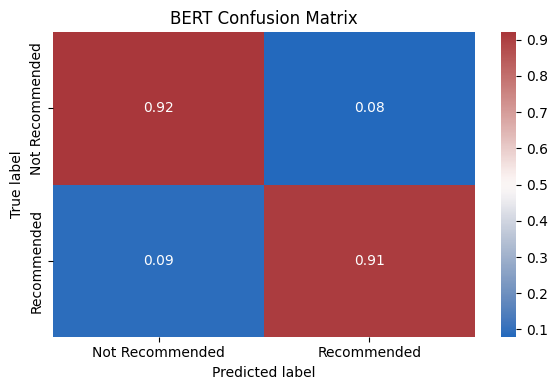

In [22]:
cm = confusion_matrix(
    y_true,
    y_pred,
    normalize='true'
).round(2)

# visualization
plt.figure(figsize=(6, 4))
sns.heatmap(
    cm,
    annot=True,
    cmap=HEATMAP_CMAP,
    xticklabels=['Not Recommended', 'Recommended'],
    yticklabels=['Not Recommended', 'Recommended']
)

plt.title('BERT Confusion Matrix')
plt.xlabel('Predicted label')
plt.ylabel('True label')

plt.tight_layout()
plt.show()


The model correctly classifies approximately 92% of not recommended reviews and 91% of recommended reviews, indicating balanced performance across both classes.

## ROC Curve

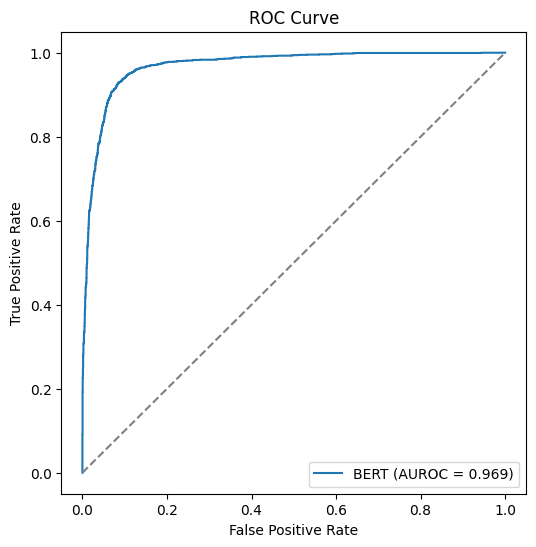

In [24]:
fpr, tpr, _ = roc_curve(y_true, y_proba)
auc = roc_auc_score(y_true, y_proba)

# visualization
plt.figure(figsize=(6, 6))

plt.plot(
    fpr,
    tpr,
    label=f'BERT (AUROC = {auc:.3f})'
)

plt.plot([0, 1], [0, 1], '--', color='gray')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc='lower right')

plt.show()

The ROC curve demonstrates strong class separability, with an AUROC of 0.969 on the test set.

## Error Analysis

In [25]:
# DataFrame for analysis (raw Review text + actual recommendation + predicted recommendation)
test_result_df = pd.DataFrame({
    'Review': test_df['Review'],
    'actual_rec': y_true,
    'predicted_rec': y_pred,
    'probability': y_proba
}, index=test_df.index)

# false positive DF
false_positive_df = test_result_df[
    (test_result_df['actual_rec'] == 0) &
    (test_result_df['predicted_rec'] == 1)
]

# false negative DF
false_negative_df = test_result_df[
    (test_result_df['actual_rec'] == 1) &
    (test_result_df['predicted_rec'] == 0)
]

In [26]:
# False Positive predictions
with pd.option_context('display.max_colwidth', None):
    display(false_positive_df.sample(7))

,Review,actual_rec,predicted_rec,probability
17171,"There is a usual Ryanair bashing, because of their usual tendency to charge everything. Once, you accept it, and follow their rules, there is no point to complain. However in FAO, we have to wait by 30 degrees Celsius, standing (no seats) on the tarmac, in a cattle corral style, in front of the aircraft, during long lasting 20 mn. We did not like it. On the contrary of many pax, we had no kids, fortunately. Flight on time, clean cabin.",0,1,0.969136
1559,MXP-MUC on a BAe 146 Y class. Good legroom excellent catering even on such a short flight. Flight attendants not smiling but doing their job. Overall a good experience followed by a smooth and easy transit in Munich.,0,1,0.984795
18399,"Operated on behalf of easyJet. Bit of a mixed bag, over an hour late. Staff appeared a little disinterested but were just about polite, but spent most of the flight behind the curtain at the front. No welcome or comms from the flight deck at anytime during the flight. Plane was tired, all a bit retro but, smooth ride, and got us home if in rather obvious low end budget fashion!",0,1,0.982978
20771,"The flight left before the scheduled time and arrived well ahead, which is always great. The aircraft was very clean and staff was nice. But Transavia doesn’t allow for online check-in, which, given the circumstances, makes even less sense than normal. Also, lines for the Paris flights were mixed.",0,1,0.986475
20348,"Outbound Thomson Airways flight to Punta Cana good with cabin crew very friendly and efficient. Drinks trolley shortly after take off, then meal service. Standard aircraft food, nothing to write home about but filling. Good entertainment on built in seat back screens. Seats had good legroom but are rather narrow. Just pray you are not sitting beside a larger person. Seat configuration not very good at 3-3-3. This only suits family's of three. Much better to have 2-5-2 or 2-4-3 this gives more flexibility and enables more people to be closer to an aisle. Return flight left a lot to be desired due to the non interested crew who were more interested in talking to each other than serving passengers. Three times I was asked what I would like to drink and each time I responded, but due to inattention and conversation with cabin crew I was literally ignored to death. Drink measures extremely small, I was given a small splash of brandy with loads of ice. Impossible to taste the brandy. They had miniatures of spirits on the trolley but would not serve them. Seats are incredibly thin and uncomfortable. They would make a fortune selling blow up pressure cushions on the flight. Breakfast served shortly before landing was sausage and omelette, which was surprisingly tasty. The Boeing 787 is a fairly comfortable aircraft but is much over hyped. Claimed to be a lot quieter than comparable aircraft. I would dispute this as I have found Airbus A330 to be quieter than this. There may be something in the claimed air quality as I have not suffered from jet lag as much as before. Overall a fairly good flight which could be greatly improved by reminding cabin crew who pays their wages. Flew as part of a package holiday with First Choice. I suppose you get what you pay for.",0,1,0.900738
14805,Bangkok to Yangon in November this year and was pleasantly surprised - not really by the condition of the aircraft (B737 ex Turkish Pegasus Charter jet) inside (narrow seats in Economy old outdated seats in Business Class) but by the fact that we were only 6 passengers on this aircraft and the service by the several flight attendants was really friendly and efficient. Food not really good in comparison to Thai Airways but well you cannot have everything.,0,1,0.984616
15052,"I won't be rushing back to fly with Norse air again. The meals are very small. The meals are tasty but quite pricey. I had chicken & mash. The snack before we landed was Sorrentina tomato and mozzarella, tasty, hot, but tiny! They give you wooden kn

In [27]:
# False Negative predictions
with pd.option_context('display.max_colwidth', None):
    display(false_negative_df.sample(7))

,Review,actual_rec,predicted_rec,probability
6846,"Bangkok to Taipei. I fail to understand why this flight and the return leg arrived at and departed from Terminal 2. The ticket specifies Terminal 1, Immigration and baggage delivery are at Terminal 1 and the return check-in is at Terminal 1. This is not the first time this has happened on a CI flight. So why does CI not have proper facilities in Terminal 2 or mark the ticket information as Terminal 2? As far as I am aware, on arrival at TPE there was no announcement on the aircraft and no printed announcement on the video monitors. Passengers were therefore left with a weakly written and seemingly unimportant sign on exiting the Gate ramp. But a China Airlines attendant stood right in front and in the middle of that sign rendering it impossible to read. And her main job seemed to be to direct passengers en route to a soon departing Fukuoka flight since the Bangkok flight had arrived late. The only sign exiting passengers can easily see is the bright illuminated sign above stating that for Immigration passengers should turn right. That, though, is for Terminal 2 Immigration and baggage claim. The handwritten sign that should be in very large thick clear lettering easily visible to all disembarking passengers pointed out that those going to Terminal 1 should actually turn left and then walk a very long way. A staff member giving instructions in Chinese is of little use to those not conversant in the language! Having been caught out by this once before and wasted almost an hour, after this flight I stopped and took time to check the sign carefully. This unthought-through action apart, the flight was smooth and the meal very tasty. My only other gripe about China Airlines is the headphones for the IFE. It makes available the ancient circular ones. I accept these fit nicely into the ears of a majority of passengers. But not all ears are the same and they just don’t fit mine at all. So even though this, with a weather delay, was only a 4-hour flight, watching anything on the IFE was out of the question.",1,0,0.010851
17286,I had to cancel one sector on my forthcoming trip to Russia and requested a refund to my credit card. I had a reply to the automated email within 20 minutes enclosing a formal refund request form and stating that it would take 15-20 working days to process. I filled in the form and sent it off again getting an acknowledgment within a few minutes and reitierating the 15-20 days. Imagine my surprise when I checked my credit card today and saw the refund (in full) only 3 days after the cancellation.,1,0,0.004860
16014,"Online check in is opened 24hr before the flight. The personal baggage is included in the ticket and carry-on luggage requires extra fee. The carry-on luggage would be charged if you didn't pay in advance. The seats are small, even though I am only 170cm tall and I got low back pain after I took a 3 hours flight.",1,0,0.019550
4814,"Short flight from Vienna to Rome. I had no issue but tolerance of excessive carry-ons led to a mad scramble slightly delaying takeoff. Crew was very nice. I had a recurring bout of back pain, and we had to go down a very long flight of stairs to a door, board a bus, then climb more stairs to the airplane. Not friendly for the mobility limited passenger.",1,0,0.081710
10915,"Hawaiian’s location at Bradley Terminal at LAX is not good! Super long walk (20 min?) to gates. There are small carts available for part of the walk. Upon return, to get to baggage claim takes even longer and is very difficult with multiple escalators. First class on LAX-LIH was so bad (more like a coach seat) that we re-routed through HNL on return for lie-flat seats. Food was terrible, but service and comfort of lie-flat seats great!",1,0,0.019653
20985,"Tunis to Rome with Tunisair. First they said that the flight was on-time. Boarding was expected at 14:10 (the flight was supposed to leave at 14:40). So I wait at the gate. 10 minutes pass, 20 minutes 

In [38]:
# general overview of the case
raw_df.iloc[6846]

,6846
Unnamed: 0,6846
Airline Name,China Airlines
Overall_Rating,6
Review_Title,"""no announcement on the aircraft"""
Review Date,21st December 2019
Verified,True
Review,Bangkok to Taipei. I fail to understand why ...
Aircraft,Boeing 747-400
Type Of Traveller,Solo Leisure
Seat Type,Economy Class


**Main categories of false predictions**:
- **Inconsistent labels**. Some reviews do not match their recommendation label. In several cases, the review text is mostly positive but labeled as not recommended, or mostly negative but labeled as recommended. This suggests that some labels in the dataset may be inconsistent.
- **Mixed reviews**. Many reviews include both positive and negative experiences. In these cases, the final recommendation depends on the author's personal opinion, making the reviews harder to classify.
- **Long reviews**. Long reviews often describe many different aspects of the journey. The author's overall opinion may appear only at the end or be expressed indirectly, making it more difficult for the model to determine the final recommendation.

# Conclusions

**BERT** achieved strong performance on the airline review classification task  on the test set:
- F1-score of 0.886,
- AUROC of 0.969.

These results confirm that transformer-based models are highly effective at capturing the context of review texts.

However, training and inference with **BERT** require substantially more computational resources and time than traditional machine learning models. Although **BERT** slightly outperformed the baseline models, the improvement over **LinearSVC** was relatively small.


| Model |  F1  | Inference | Deployment |
| :--- |:----:| :---: | :--- |
| LinearSVC | 0.87 | Fast | Selected |
| BERT | 0.89 | Slow | Experimental |



Therefore, **LinearSVC** was selected as the final model because it offers a good balance between performance, speed, and computational cost. The deployment API will also be based on the **LinearSVC** model.